In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


In [2]:
g = 9.81    
H = 1.0    
c = np.sqrt(g*H)

L = 1.0     
Nx = 400    
dx = L / Nx

CFL = 0.9   
T_end = 0.5 


A = 0.01         
sigma = 0.05*L   


dt = CFL * dx / c
steps = int(np.ceil(T_end / dt))
dt = T_end / steps 

print(f"c = {c:.6f} м/с, dx = {dx:.6e} м, dt = {dt:.6e} с, steps = {steps}")


c = 3.132092 м/с, dx = 2.500000e-03 м, dt = 7.173601e-04 с, steps = 697


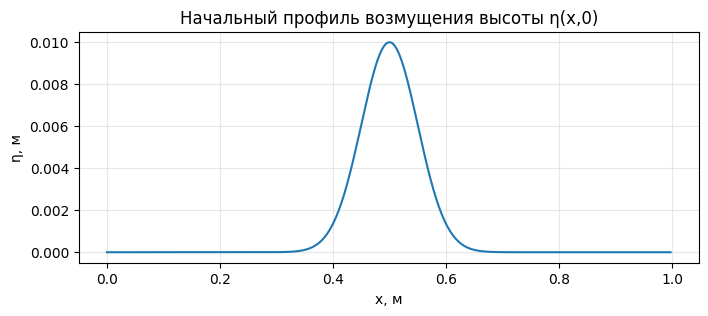

In [3]:
x = np.linspace(0.0, L, Nx, endpoint=False)
x0 = 0.5*L  

def eta0(xx):
    d = np.minimum(np.abs(xx - x0), L - np.abs(xx - x0))  
    return A * np.exp(-(d**2) / (2*sigma**2))

eta = eta0(x)
u = np.zeros_like(x)

fig, ax = plt.subplots(figsize=(8,3))
ax.plot(x, eta)
ax.set_title('Начальный профиль возмущения высоты η(x,0)')
ax.set_xlabel('x, м')
ax.set_ylabel('η, м')
ax.grid(True, alpha=0.3)
plt.show()


In [4]:
def flux(eta, u):
    return H*u, g*eta

def lax_friedrichs_step(eta, u, dt, dx):
    # периодические сдвиги
    eta_p = np.roll(eta, -1)
    eta_m = np.roll(eta, +1)
    u_p   = np.roll(u,   -1)
    u_m   = np.roll(u,   +1)

    F1_p, F2_p = flux(eta_p, u_p)
    F1_m, F2_m = flux(eta_m, u_m)

    eta_new = 0.5*(eta_p + eta_m) - 0.5*(dt/dx)*(F1_p - F1_m)
    u_new   = 0.5*(u_p   + u_m  ) - 0.5*(dt/dx)*(F2_p - F2_m)
    return eta_new, u_new


In [5]:
def eta_analytical(x, t):
    return 0.5*(eta0((x - c*t) % L) + eta0((x + c*t) % L))

def u_analytical(x, t):
    # u(x,t) = (g/(2c)) [eta0(x-ct) - eta0(x+ct)]
    return (g/(2*c))*(eta0((x - c*t) % L) - eta0((x + c*t) % L))


In [6]:
snapshots_t = [0.0, 0.25*T_end, 0.5*T_end, T_end]
snap_eta_num, snap_u_num = [], []
snap_eta_ana, snap_u_ana = [], []

t = 0.0

def maybe_store_snap(t_curr):
    for tt in snapshots_t:
        if not hasattr(maybe_store_snap, "done"):
            maybe_store_snap.done = set()
        if tt not in maybe_store_snap.done and abs(t_curr-tt) <= 0.5*dt:
            snap_eta_num.append(eta.copy())
            snap_u_num.append(u.copy())
            snap_eta_ana.append(eta_analytical(x, tt))
            snap_u_ana.append(u_analytical(x, tt))
            maybe_store_snap.done.add(tt)

maybe_store_snap(t)

for _ in range(steps):
    eta, u = lax_friedrichs_step(eta, u, dt, dx)
    t += dt
    maybe_store_snap(t)

eta_e = eta_analytical(x, T_end)
u_e = u_analytical(x, T_end)
l2_eta = np.sqrt(np.mean((eta - eta_e)**2))
l2_u = np.sqrt(np.mean((u - u_e)**2))
print(f"L2-ошибка η в t=T_end: {l2_eta:.3e}")
print(f"L2-ошибка u в t=T_end: {l2_u:.3e}")


L2-ошибка η в t=T_end: 1.860e-04
L2-ошибка u в t=T_end: 9.600e-04


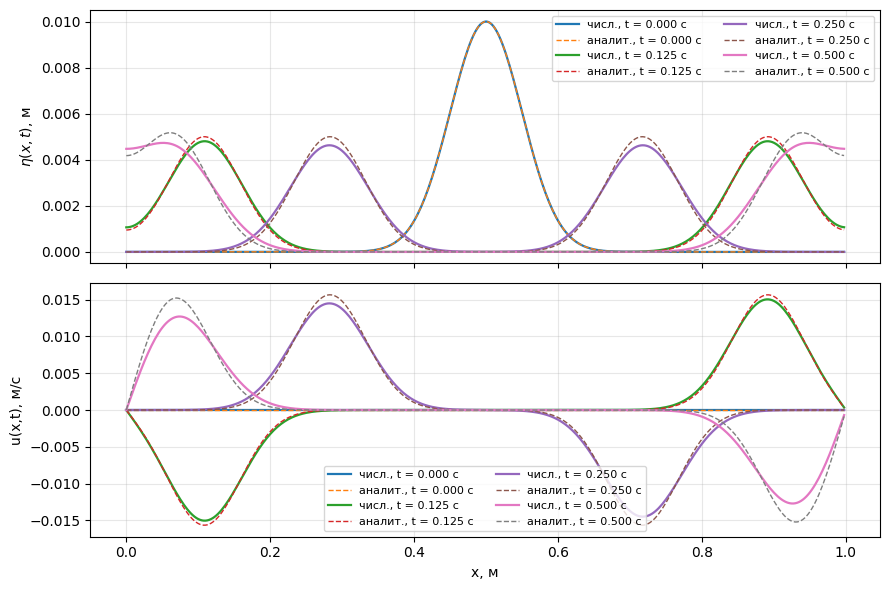

In [7]:
labels = [f"t = {tt:.3f} c" for tt in snapshots_t]

fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

for k, lab in enumerate(labels):
    axes[0].plot(x, snap_eta_num[k], lw=1.6, label=f"числ., {lab}")
    axes[0].plot(x, snap_eta_ana[k], ls='--', lw=1.0, label=f"аналит., {lab}")

axes[0].set_ylabel(r"$\eta(x,t)$, м")
axes[0].grid(True, alpha=0.3)
axes[0].legend(ncols=2, fontsize=8)

for k, lab in enumerate(labels):
    axes[1].plot(x, snap_u_num[k], lw=1.6, label=f"числ., {lab}")
    axes[1].plot(x, snap_u_ana[k], ls='--', lw=1.0, label=f"аналит., {lab}")

axes[1].set_xlabel('x, м')
axes[1].set_ylabel('u(x,t), м/с')
axes[1].grid(True, alpha=0.3)
axes[1].legend(ncols=2, fontsize=8)

plt.tight_layout()
plt.show()
